# Notebook 1: Pre-processing of 10X Single-Cell RNA Datasets

**Objective:** Load raw scRNA-seq data, perform quality control, filter low-quality cells and genes, normalize, log-transform, and identify highly variable genes.

**Reference:** [Galaxy Training — Pre-processing of 10X Single-Cell RNA Datasets](https://training.galaxyproject.org/training-material/topics/single-cell/tutorials/scrna-preprocessing-tenx/tutorial.html)

**Dataset:** PBMC 3k from 10X Genomics (2,700 peripheral blood mononuclear cells from a healthy donor)

## 1. Setup and Imports

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')
sc.settings.figdir = 'output_data/'

print(f"Scanpy version: {sc.__version__}")

Scanpy version: 1.11.5


C:\Users\Asim\AppData\Local\Temp\ipykernel_7408\3280139594.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


## 2. Loading the Data

The 10X Genomics CellRanger pipeline outputs three files:
- `matrix.mtx` — sparse UMI count matrix
- `barcodes.tsv` — cell barcode sequences
- `genes.tsv` / `features.tsv` — gene identifiers

Scanpy reads these with `sc.read_10x_mtx()`. Here we use the built-in PBMC3K dataset.

In [2]:
# Option A: Read from 10X CellRanger output folder
# adata = sc.read_10x_mtx(
#     'data/filtered_gene_bc_matrices/hg19/',
#     var_names='gene_symbols',
#     cache=True
# )

# Option B: Load built-in PBMC 3k dataset
adata = sc.datasets.pbmc3k()
print(adata)

try downloading from url
https://falexwolf.de/data/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


### 2.1 Initial Data Inspection

In [3]:
print(f"Number of cells (observations): {adata.n_obs}")
print(f"Number of genes (variables):    {adata.n_vars}")
print(f"\nFirst 5 cell barcodes: {adata.obs_names[:5].tolist()}")
print(f"First 5 gene names:    {adata.var_names[:5].tolist()}")
print(f"\nExpression matrix shape: {adata.X.shape}")
print(f"Matrix type (sparse): {type(adata.X)}")

Number of cells (observations): 2700
Number of genes (variables):    32738

First 5 cell barcodes: ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
First 5 gene names:    ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']

Expression matrix shape: (2700, 32738)
Matrix type (sparse): <class 'scipy.sparse._csr.csr_matrix'>


## 3. Quality Control (QC)

Low-quality cells must be removed before analysis. Three standard QC metrics are used:

| Metric | Meaning | Concern |
|--------|---------|---------|
| `n_genes_by_counts` | Genes detected per cell | Too few = empty droplet or dead cell |
| `total_counts` | Total UMI counts per cell | Too few = poor capture efficiency |
| `pct_counts_mt` | % mitochondrial gene counts | High % = damaged/dying cell |

Mitochondrial genes are prefixed with "MT-" in human data.

In [4]:
# Ensure unique gene names
adata.var_names_make_unique()

# Annotate mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")
print(f"Names: {adata.var_names[adata.var['mt']].tolist()}")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print(f"\nQC columns added to adata.obs: {list(adata.obs.columns)}")
print(f"\nBasic statistics:")
print(f"  Mean genes per cell:    {adata.obs['n_genes_by_counts'].mean():.1f}")
print(f"  Mean UMIs per cell:     {adata.obs['total_counts'].mean():.1f}")
print(f"  Mean mitochondrial %:   {adata.obs['pct_counts_mt'].mean():.2f}%")

Mitochondrial genes found: 13
Names: ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']

QC columns added to adata.obs: ['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']

Basic statistics:
  Mean genes per cell:    847.0
  Mean UMIs per cell:     2366.9
  Mean mitochondrial %:   2.22%


### 3.1 Violin Plots of QC Metrics

Violin plots show the distribution of each QC metric across all cells, helping us pick filtering thresholds.

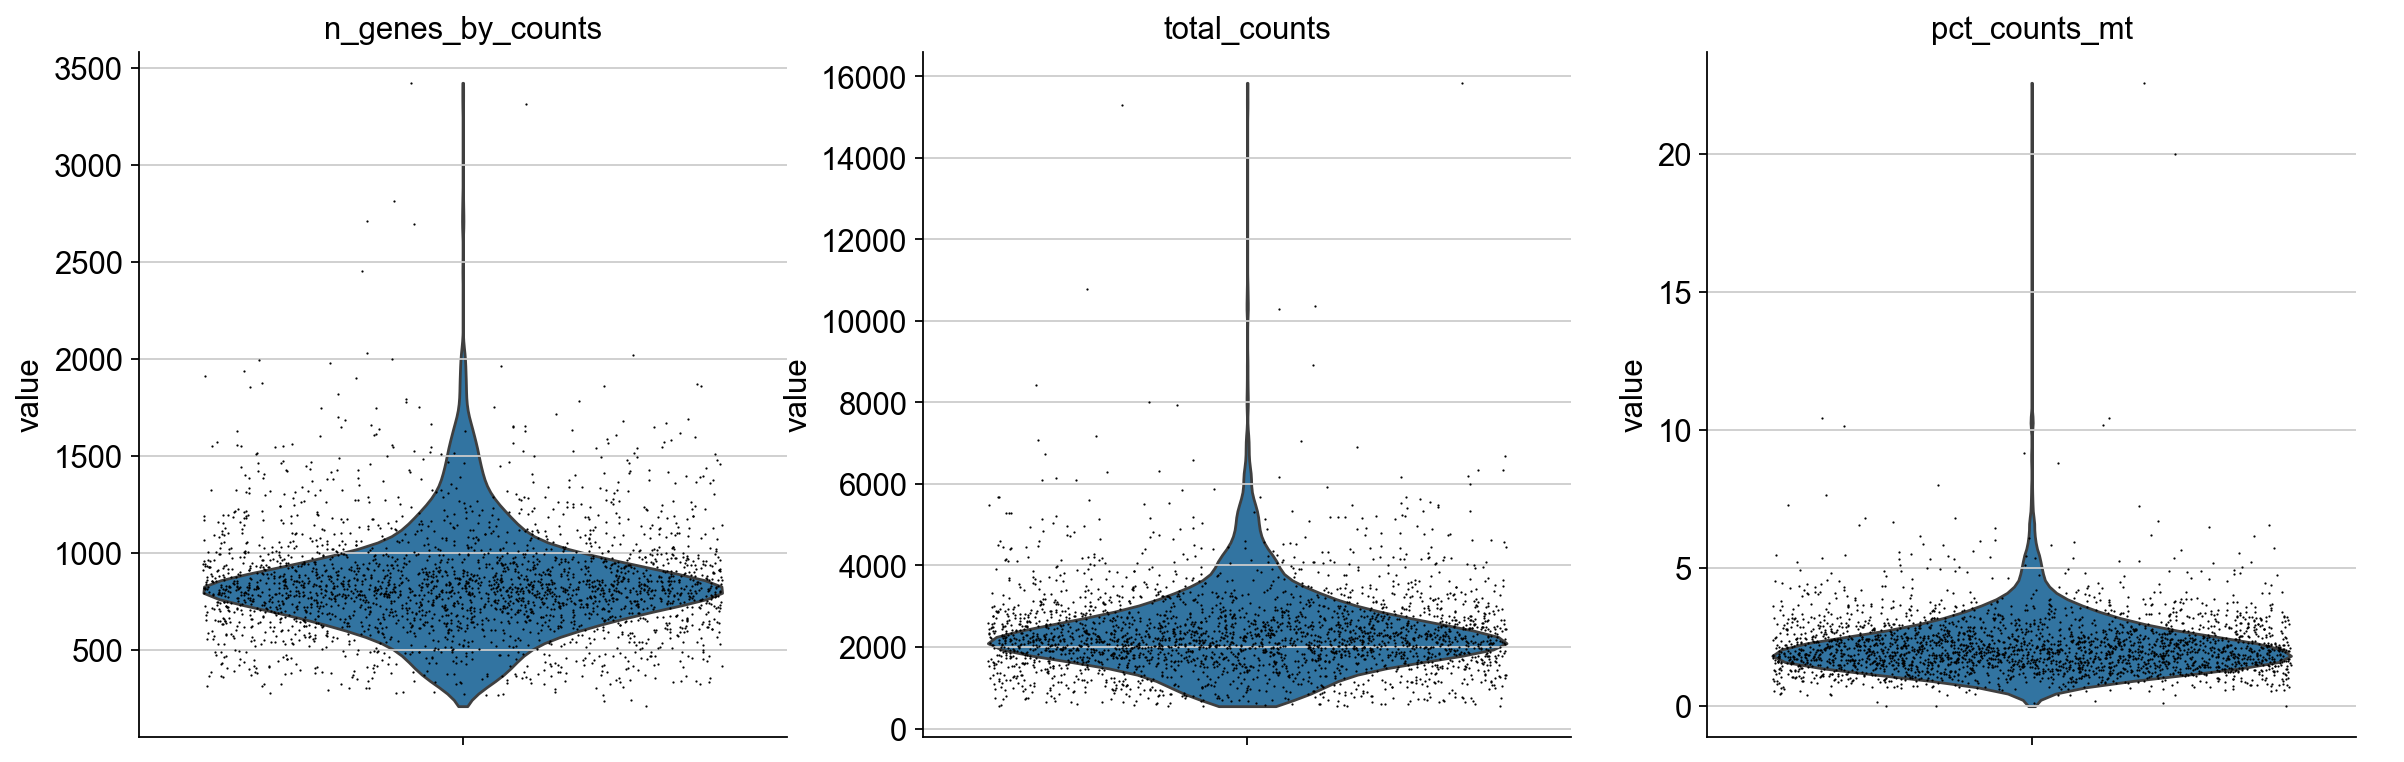

In [5]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    save='_qc_metrics.png'
)
plt.show()

### 3.2 Scatter Plots of QC Metrics

Scatter plots reveal relationships between metrics:
- High gene counts + high total counts = potential doublets
- High mitochondrial % at any library size = damaged cells

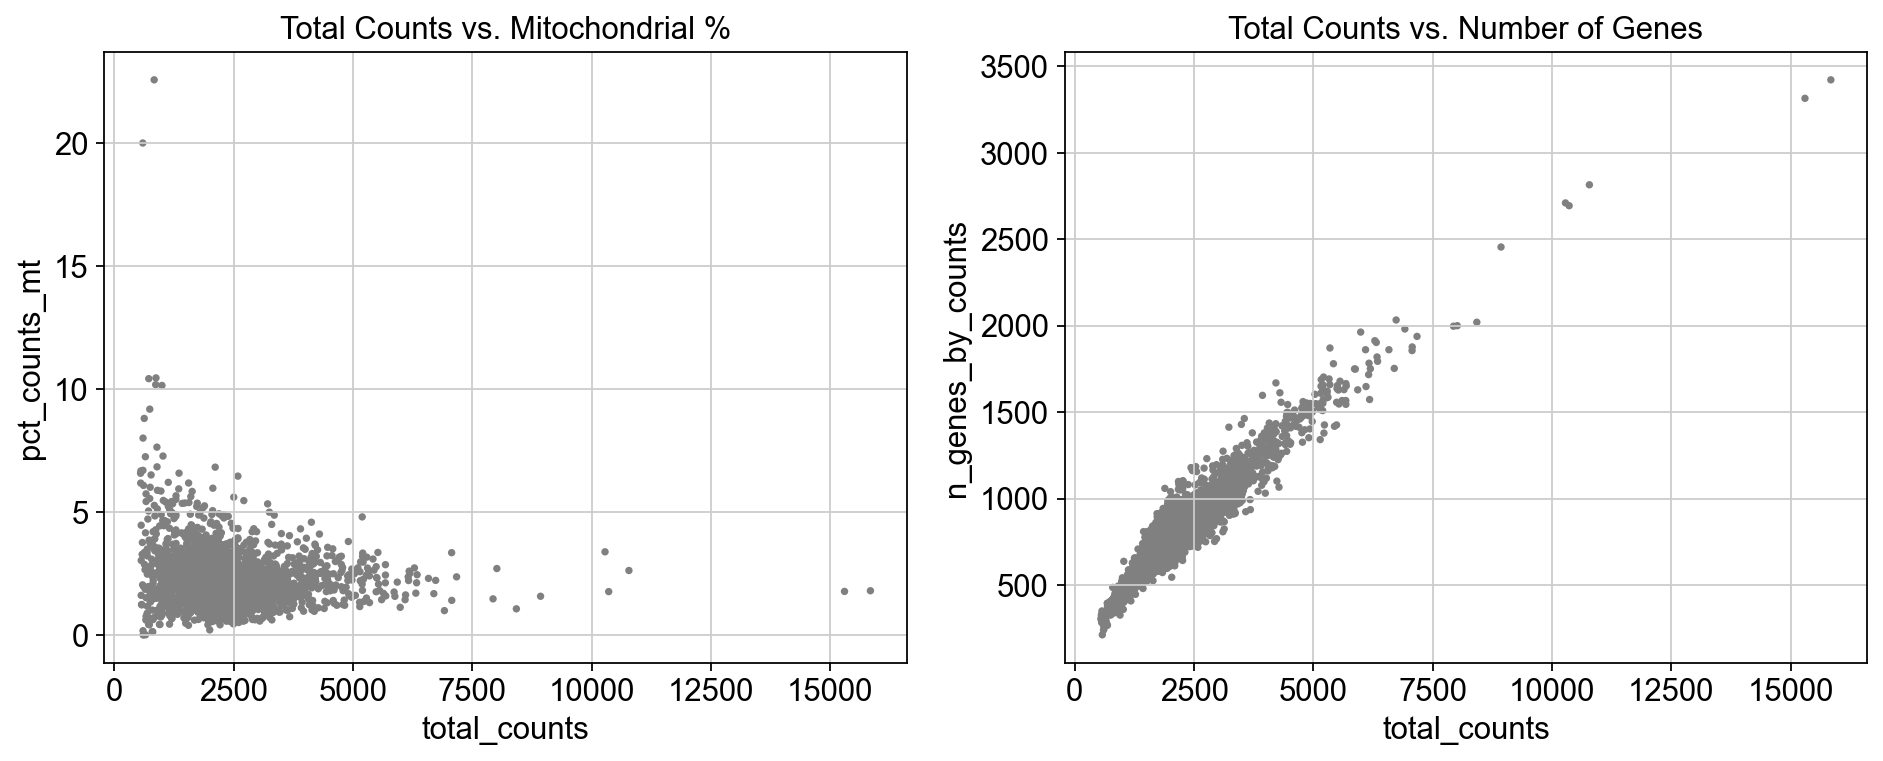

Scatter plots saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', ax=axes[0], show=False)
axes[0].set_title('Total Counts vs. Mitochondrial %')

sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', ax=axes[1], show=False)
axes[1].set_title('Total Counts vs. Number of Genes')

plt.tight_layout()
plt.savefig('output_data/scatter_qc_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved.")

### 3.3 Highest Expressed Genes

Shows which genes dominate expression across cells. Mitochondrial and ribosomal genes often appear at the top.

normalizing counts per cell
    finished (0:00:04)


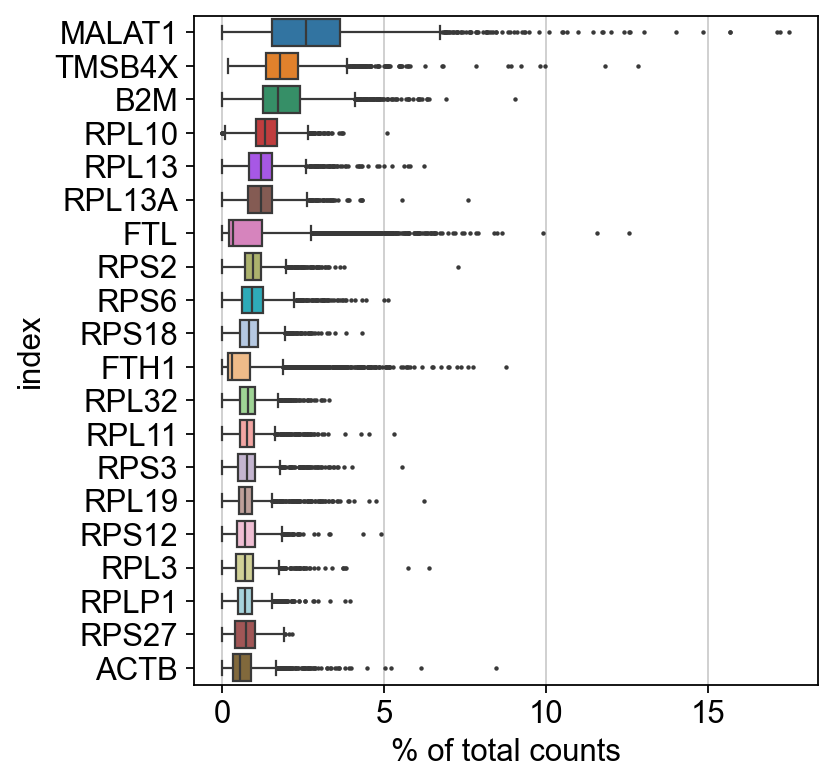

In [7]:
sc.pl.highest_expr_genes(adata, n_top=20, save='_top20.png')
plt.show()

## 4. Filtering Cells and Genes

Based on QC distributions above, we apply these thresholds:
- **Min genes/cell:** 200 (remove empty droplets)
- **Min cells/gene:** 3 (remove barely-detected genes)
- **Max genes/cell:** 2,500 (remove potential doublets)
- **Max MT %:** 5% (remove damaged/dying cells)

In [8]:
print(f"Cells BEFORE filtering: {adata.n_obs}")
print(f"Genes BEFORE filtering: {adata.n_vars}")

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Remove doublets and dying cells
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

print(f"\nCells AFTER filtering:  {adata.n_obs}")
print(f"Genes AFTER filtering:  {adata.n_vars}")

Cells BEFORE filtering: 2700
Genes BEFORE filtering: 32738
filtered out 19024 genes that are detected in less than 3 cells

Cells AFTER filtering:  2638
Genes AFTER filtering:  13714


## 5. Normalization and Log-Transformation

1. **Normalize** each cell to 10,000 total counts (library-size normalization)
2. **Log-transform** with `log1p = log(x + 1)` to stabilize variance

In [9]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("Normalization and log-transformation complete.")

normalizing counts per cell
    finished (0:00:00)
Normalization and log-transformation complete.


## 6. Identify Highly Variable Genes (HVGs)

HVGs show the most biological variation between cells and are used for dimensionality reduction and clustering.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes selected: 1838
Total genes considered: 13714


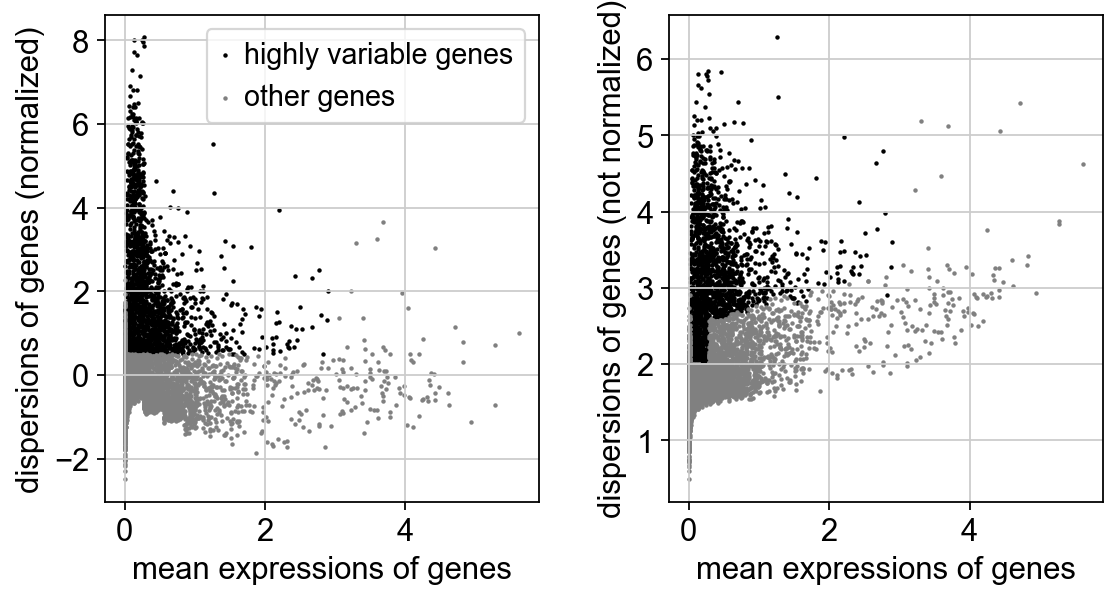

In [10]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

print(f"Highly variable genes selected: {adata.var.highly_variable.sum()}")
print(f"Total genes considered: {adata.n_vars}")

sc.pl.highly_variable_genes(adata, save='_hvg.png')
plt.show()

## 7. Freeze Raw Data and Subset to HVGs

We store the full normalized matrix in `adata.raw` so all genes remain accessible later (e.g. for marker gene plotting on UMAP). The main matrix is subsetted to HVGs only.

In [11]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
print(f"Matrix now: {adata.shape[0]} cells x {adata.shape[1]} HVGs")

Matrix now: 2638 cells x 1838 HVGs


## 8. Regress Out Confounders and Scale

We regress out confounding effects of total counts and mitochondrial percentage so they do not drive clustering. Then we scale each gene to unit variance, clipping extreme values at 10.

In [12]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
print("Regression and scaling complete.")

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


C:\Users\Asim\anaconda3\envs\scrna_env\lib\site-packages\scanpy\preprocessing\_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\Asim\anaconda3\envs\scrna_env\lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
C:\Users\Asim\anaconda3\envs\scrna_env\lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:05)
Regression and scaling complete.


## 9. Save Preprocessed Data

Save the fully preprocessed AnnData object for use in Notebook 2.

In [13]:
adata.write('output_data/preprocessed_adata.h5ad')
print(f"Saved: output_data/preprocessed_adata.h5ad")
print(f"\nFinal AnnData object:")
print(adata)

Saved: output_data/preprocessed_adata.h5ad

Final AnnData object:
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'


---
## Summary

| Step | Function | Purpose |
|------|----------|---------|
| Load data | `sc.datasets.pbmc3k()` | Read 10X count matrix into AnnData |
| QC metrics | `sc.pp.calculate_qc_metrics()` | Compute n_genes, total_counts, pct_mt |
| Visualize QC | `sc.pl.violin()`, `sc.pl.scatter()` | Inspect distributions, pick thresholds |
| Filter cells/genes | `sc.pp.filter_cells/genes()` | Remove empty, doublets, dying cells |
| Normalize | `sc.pp.normalize_total()` | Correct for library size differences |
| Log-transform | `sc.pp.log1p()` | Stabilize variance |
| HVGs | `sc.pp.highly_variable_genes()` | Select informative genes |
| Regress out | `sc.pp.regress_out()` | Remove confounder effects |
| Scale | `sc.pp.scale()` | Standardize gene expression |